# EXPLORATORI DATA ANALYSIS

Now that we have our corpus clean, and before testing our hypotheses, we are doing some exploratory data analysis to ensure that the data met our assumptions.

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

In [9]:
df = pd.read_pickle("obituaries_lemma.pkl")
df['year'] = pd.to_datetime(df['date']).dt.year

Let's we the number of documents that we have, and check that the number of men vs women per year is balanced.

Number of documents:  215160
Documents per year by gender:
 gender     F     M
year              
2002    1384  1247
2003    1876  1772
2004    2380  2074
2005    3116  2793
2006    3916  3545
2007    4718  4145
2008    3978  3675
2009    6301  5782
2010    6642  6174
2011    6778  6403
2012    6551  6002
2013    6283  5999
2014    5852  5646
2015    5978  5753
2016    5793  5679
2017    5441  5565
2018    4991  4810
2019    4467  4454
2020    4759  4810
2021    3072  3181
2022    4519  4608
2023    3906  4127
2024    3612  3548
2025    3445  3610


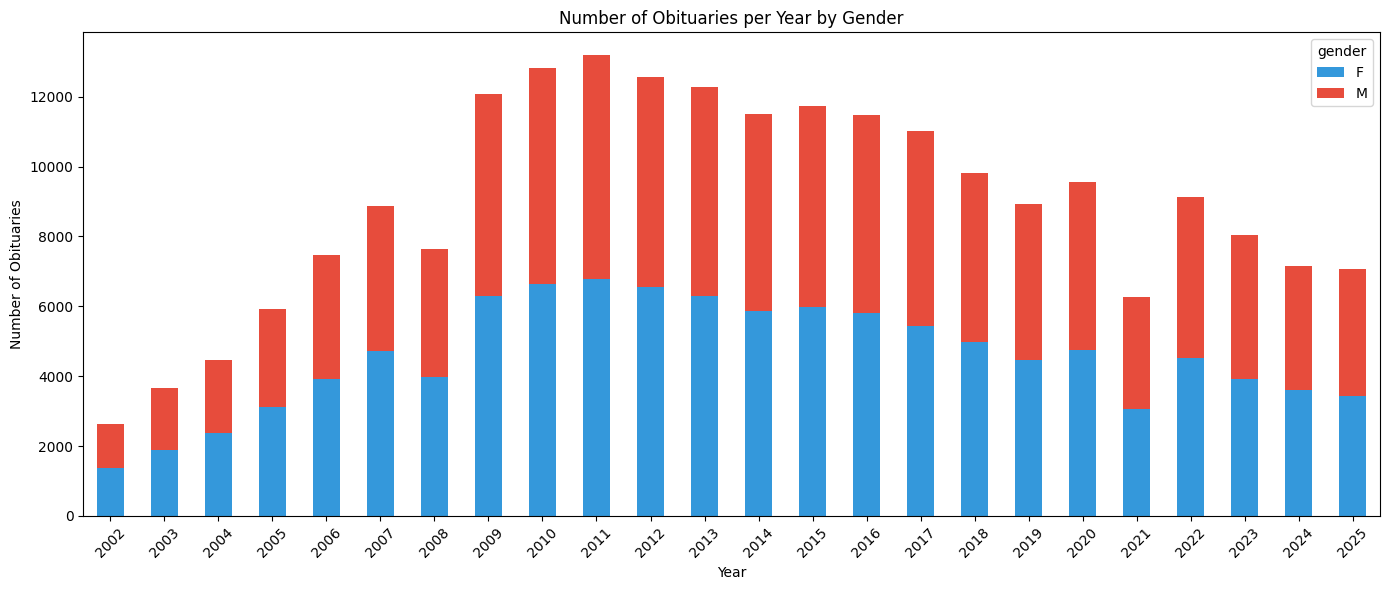

In [10]:
print("Number of documents: ", df.shape[0])

doc_counts = df.groupby(['year', 'gender']).size().unstack(fill_value=0)
print("Documents per year by gender:\n", doc_counts)

# Plot
doc_counts.plot(kind='bar', stacked=True, figsize=(14,6), color=['#3498db','#e74c3c'])
plt.title("Number of Obituaries per Year by Gender")
plt.xlabel("Year")
plt.ylabel("Number of Obituaries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The dataset contains a total of 215,160 obituaries from 2002 to 2025. The number of documents is well balanced between genders each year, with female and male obituaries generally differing by only a few hundred at most. Each year has a substantial number of entries, ranging from over 1,200 to more than 6,700 documents per gender, providing a large and representative sample. This ensures that the data is sufficiently robust and minimizes concerns about variability or bias due to uneven or small sample sizes. Overall, the dataset offers a solid foundation for reliable analysis across the entire period.

Let's now examine aspects related to the length of the texts:


           count       mean        std  min   25%   50%   75%     max
gender                                                               
F       109758.0  28.645657  31.564679  0.0  10.0  20.0  36.0  1253.0
M       105402.0  32.560350  35.654263  0.0  12.0  23.0  41.0  2443.0


/var/folders/n9/kv5pq1015h5cxdk8s76mbdxw0000gn/T/ipykernel_59053/120511480.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y='text_length', data=df, palette={'M':'#3498db','F':'#e74c3c'})


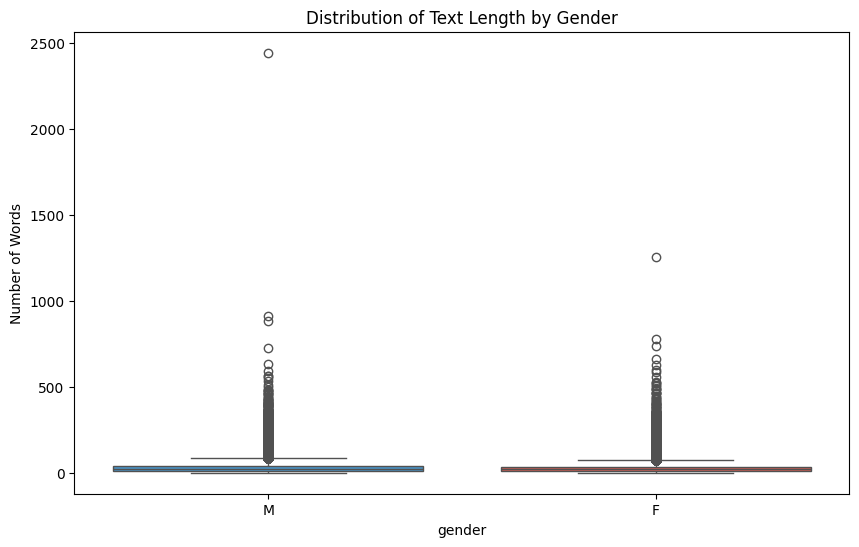

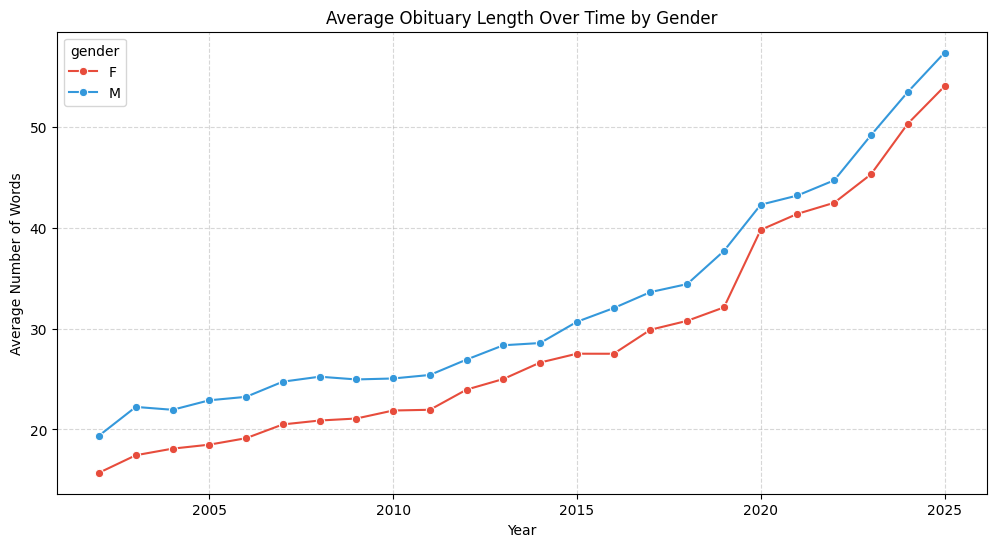

In [14]:
df['text_length'] = df['text_clean'].apply(lambda x: len(str(x).split()))
print(df.groupby('gender')['text_length'].describe())

# Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(x='gender', y='text_length', data=df, palette={'M':'#3498db','F':'#e74c3c'})
plt.title("Distribution of Text Length by Gender")
plt.ylabel("Number of Words")
plt.show()

avg_length = df.groupby(['year','gender'])['text_length'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=avg_length, x='year', y='text_length', hue='gender', palette={'M':'#3498db','F':'#e74c3c'}, marker='o')
plt.title("Average Obituary Length Over Time by Gender")
plt.ylabel("Average Number of Words")
plt.xlabel("Year")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

The first boxplots show that the distributions are quite similar for men and women, although the median and mean text lengths are slightly higher for male obituaries (mean ≈ 29 words for men vs. ≈ 33 for women). Both genders display outliers with very long texts, but these extreme cases are rare and do not dominate the overall distributions.

The line plot of average text length per year shows a generally increasing trend over time for both genders, with the two lines running roughly in parallel. This indicates that while obituaries have grown slightly longer over the years, the difference in average length between men and women has remained fairly consistent.

The fact that document lengths are not exactly the same between men and women, and vary over the years, is something we need to keep in mind when conducting the study. For example, when creating indices or calculating relative measures, we will need to normalize by the number of words.

Now we are going to examine one of the most important aspects: the distribution of words in the corpus. Understanding this distribution is essential for properly interpreting the results.

           word  doc_frequency
18         year         114898
16       family          86361
61         love          80045
14         work          77902
218        wife          76772
23        enjoy          76748
146      member          76487
312     husband          72018
26       friend          65167
44         late          60093
132    graduate          56336
64         time          55937
235      sister          55414
216  grandchild          54761
56      brother          49152
183       great          49009
270       niece          47388
98         life          45989
154       serve          44550
21       nephew          44438
294      retire          40495
185      attend          38895
237     include          38223
287       leave          37134
164       spend          36398
564         son          34929
555    daughter          34872
204       child          33114
15         live          30310
626      mother          29108
200      employ          26764
328     

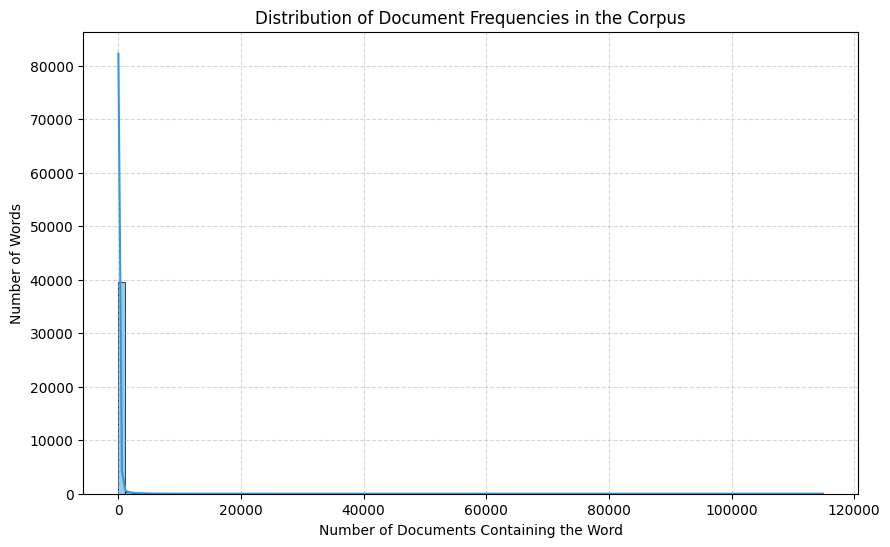

In [ ]:
docs_words = df['text_clean'].dropna().apply(lambda x: set(x.lower().split()))

word_doc_counter = Counter()
for word_set in docs_words:
    word_doc_counter.update(word_set)

freq_df = pd.DataFrame(word_doc_counter.items(), columns=['word', 'doc_frequency']).sort_values(by='doc_frequency', ascending=False)


print(freq_df.head(50))

frequencies = np.array(list(word_doc_counter.values()))

# Plot of density
plt.figure(figsize=(10,6))
sns.histplot(frequencies, bins=100, kde=True, color='#3498db')
plt.title("Distribution of Document Frequencies in the Corpus")
plt.xlabel("Number of Documents Containing the Word")
plt.ylabel("Number of Words")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Even looking at the top 50 words by document frequency, there is a huge gap between the first and the 50th word: the first appears in 114,898 documents, while the 50th appears in 18,176. This clearly illustrates Zipf’s law in our corpus. The full distribution shows that most words appear in very few obituaries, clustering near zero, while a few words appear in tens of thousands of documents. These results suggest that, in later steps, we should weight words appropriately—otherwise, very common words could overshadow the distinctive language that differentiates obituaries. To capture the unique essence of each obituary, it will be important to focus on terms that do not appear in every document, so that highly frequent, generic words do not dominate the analysis. Considering this will allow us to better distinguish the language used in individual obituaries and across different groups.

It's interesting to see that the most common words are consistent across groups:

In [ ]:
def top_words_by_gender(df, gender, top_n):
    texts = df[df['gender'] == gender]['text_clean'].dropna()
    all_words = " ".join(texts).lower().split()
    word_counts = Counter(all_words)
    return pd.DataFrame(word_counts.most_common(top_n), columns=['word', 'frequency'])

top_female = top_words_by_gender(df, 'F', top_n=10)
top_male = top_words_by_gender(df, 'M', top_n=10)

print("Top 10 words in female obituaries:")
print(top_female)

print("\nTop 10 words in male obituaries:")
print(top_male)

Top 10 words in female obituaries:
         word  frequency
0        year      88796
1      family      77049
2        love      74955
3        wife      63254
4     husband      56494
5  grandchild      51494
6        late      49998
7      member      49722
8        work      48892
9       enjoy      47639

Top 10 words in male obituaries:
      word  frequency
0     year     104451
1     love      65848
2   family      64213
3     wife      61864
4   member      60135
5  husband      56132
6     work      56009
7    serve      48921
8    enjoy      48607
9   friend      43642


Looking at the top 10 most frequent words in female and male obituaries, we can see a clear pattern: the lists are dominated by highly common terms such as year, family, love, wife, husband, and member. These words appear in the majority of obituaries for both genders and carry little discriminative information about the unique content of each text.

These results provide strong evidence that, if we want to meaningfully compare the language used in male and female obituaries, we will need to downweight or exclude such highly frequent words. Otherwise, the similarity between the groups will be dominated by these generic, non-informative terms, which do not reflect the distinctive ways in which the lives of men and women are described. Focusing on less frequent, more specific words will be crucial to capture the actual semantic differences and nuances in the obituaries’ narratives.